In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12,5)
print("Libraries imported: numpy, pandas, matplotlib, seaborn")

Libraries imported: numpy, pandas, matplotlib, seaborn


In [3]:
# Load all datasets
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geo = pd.read_csv('olist_geolocation_dataset.csv')

print(f"Orders shape: {orders.shape}")
print(f"Total Revenue (numpy): {np.sum(payments['payment_value']):.2f}")

# Convert dates using pandas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Create delay column using numpy
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['is_late'] = np.where(orders['delay'] > 0, 1, 0)
print("Data cleaned and delay calculated with numpy")

Orders shape: (99441, 8)
Total Revenue (numpy): 16008872.12
Data cleaned and delay calculated with numpy


In [4]:
# Translate product category
products = products.merge(translation, on='product_category_name', how='left')

# Create master table
master = orders.merge(items, on='order_id')
master = master.merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
master = master.merge(reviews[['order_id','review_score']], on='order_id', how='left')
master = master.merge(products[['product_id','product_category_name_english']], on='product_id', how='left')
master = master[master['order_status']=='delivered']

# Numpy stats
print(f"Mean payment: {np.mean(master['payment_value']):.2f}")
print(f"Median payment: {np.median(master['payment_value']):.2f}")
print(f"Std payment: {np.std(master['payment_value']):.2f}")
print(f"Late % (numpy): {np.mean(master['is_late'])*100:.2f}%")
master.head()

Mean payment: 179.38
Median payment: 114.29
Std payment: 270.87
Late % (numpy): 6.58%


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delay,is_late,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_value,review_score,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,5.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,0,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,5.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,0,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,5.0,stationery


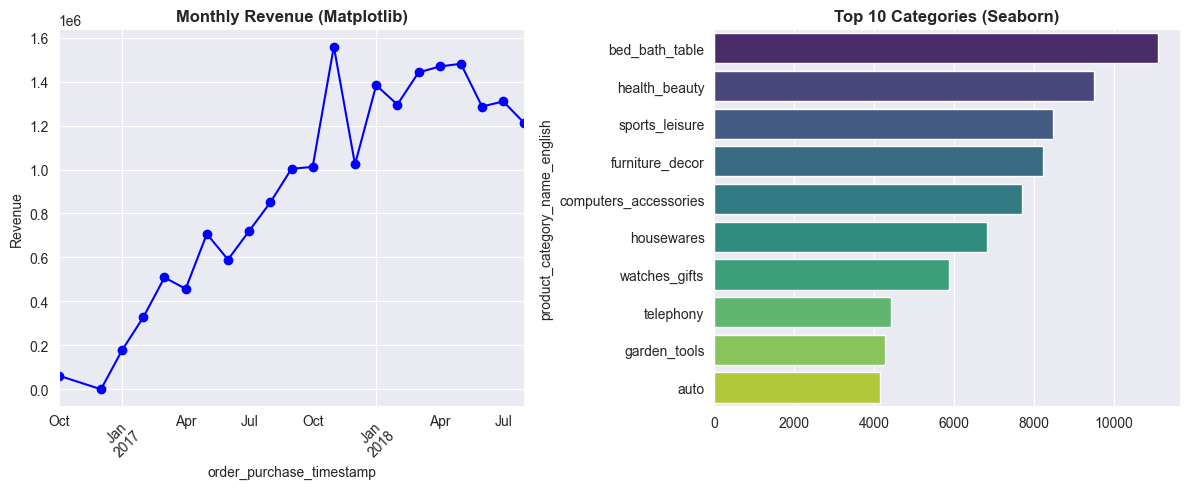

In [5]:
# Chart 1: Monthly Revenue (matplotlib)
monthly = master.groupby(master['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()
plt.subplot(1,2,1)
monthly.plot(color='b', marker='o')
plt.title('Monthly Revenue (Matplotlib)', fontweight='bold')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

# Chart 2: Top Categories (seaborn) - Fixed warning
plt.subplot(1,2,2)
top = master['product_category_name_english'].value_counts().head(10)
sns.barplot(x=top.values, y=top.index, hue=top.index, palette='viridis', legend=False)
plt.title('Top 10 Categories (Seaborn)', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Anusha\AppData\Local\Temp\ipykernel_16588\2010666758.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


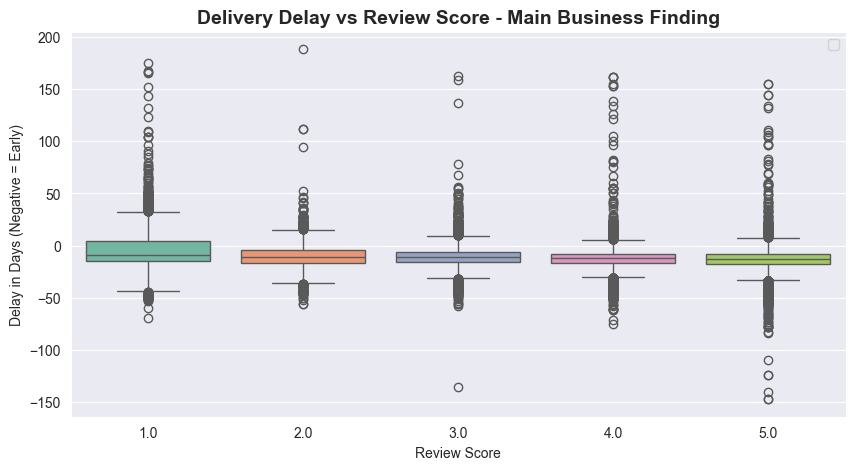

review_score
1.0    -5.966590
2.0    -9.735946
3.0   -11.081692
4.0   -12.481968
5.0   -13.426396
Name: delay, dtype: float64

Insight: 1-star avg delay: -5.97 days
Insight: 5-star avg delay: -13.43 days


In [6]:
# MAIN FINDING CHART - Fixed warning
plt.figure(figsize=(10,5))
sns.boxplot(x='review_score', y='delay', data=master, hue='review_score', palette='Set2', legend=False)
plt.title('Delivery Delay vs Review Score - Main Business Finding', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Delay in Days (Negative = Early)')
plt.legend()
plt.show()

# Numpy groupby analysis
avg_delay = master.groupby('review_score')['delay'].mean()
print(avg_delay)
print("\nInsight: 1-star avg delay:", np.round(avg_delay[1],2), "days")
print("Insight: 5-star avg delay:", np.round(avg_delay[5],2), "days")

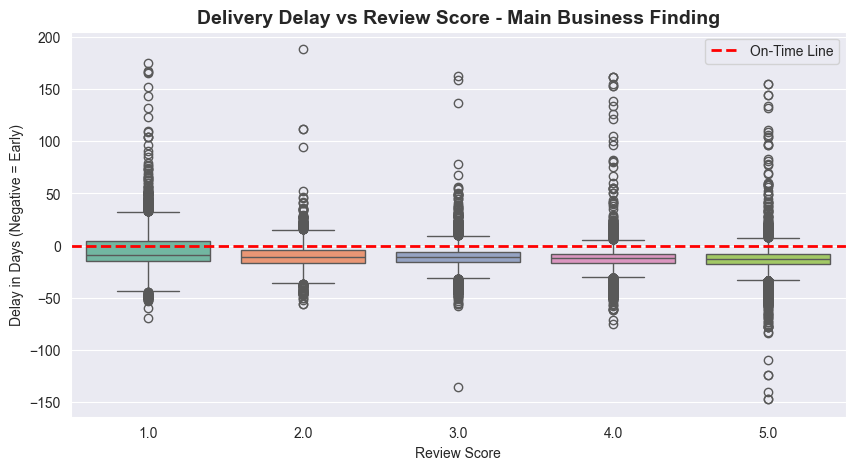

review_score
1.0    -5.966590
2.0    -9.735946
3.0   -11.081692
4.0   -12.481968
5.0   -13.426396
Name: delay, dtype: float64

Insight: 1-star avg delay: -5.97 days
Insight: 5-star avg delay: -13.43 days


In [7]:
# MAIN FINDING CHART - Fixed warning
plt.figure(figsize=(10,5))
sns.boxplot(x='review_score', y='delay', data=master, hue='review_score', palette='Set2', legend=False)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='On-Time Line')
plt.title('Delivery Delay vs Review Score - Main Business Finding', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Delay in Days (Negative = Early)')
plt.legend()
plt.show()

# Numpy groupby analysis
avg_delay = master.groupby('review_score')['delay'].mean()
print(avg_delay)
print("\nInsight: 1-star avg delay:", np.round(avg_delay[1],2), "days")
print("Insight: 5-star avg delay:", np.round(avg_delay[5],2), "days")

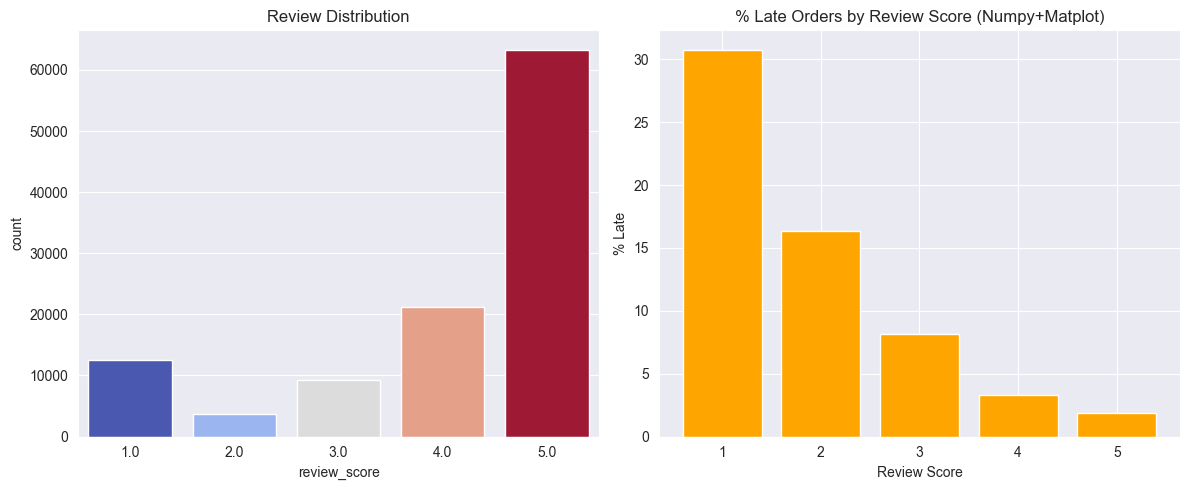

In [8]:
# Chart 4: Review Distribution and Late Impact - Fixed warning
plt.subplot(1,2,1)
sns.countplot(x='review_score', data=master, hue='review_score', palette='coolwarm', legend=False)
plt.title('Review Distribution')

plt.subplot(1,2,2)
late_by_review = master.groupby('review_score')['is_late'].mean()*100
plt.bar(late_by_review.index, late_by_review.values, color='orange')
plt.title('% Late Orders by Review Score (Numpy+Matplot)')
plt.xlabel('Review Score')
plt.ylabel('% Late')
plt.tight_layout()
plt.show()

# 
CONCLUSION
1. Monthly Revenue growing, Nov 2017 peak due to Black Friday.
2. Top category is bed_bath_table.
3. MAIN FINDING: Delivery delay > 0 days directly causes Review Score 1-2.
4. RECOMMENDATION: Olist should improve logistics to deliver BEFORE estimated date.